# Quantum Algorithms

## Deutsch-Jozsa problem

Suppose we are given access to a function $f$ that takes as input a bit string (e.g., $0010110$) and returns a single bit ($0$ or $1$).

We may query this function as many times as we like, but we have no knowledge of its internal structure. The only information provided is that the function is guaranteed to be either balanced or constant.

* The function is balanced if it returns $0$ for exactly half of the possible input strings and $1$ for the other half.
* The function is constant if it always returns the same value — either always $0$ or always $1$ — for every possible input bit string.

The **Deutsch–Jozsa problem** consists of determining whether the function $f$ is constant or balanced.

A classical approach to solving this problem is to evaluate $f$ on different input bit strings. For example, if we obtain two different outputs, then the function must be balanced, since it cannot be constant (and we are guaranteed that it is either constant or balanced). However, this strategy can be time-consuming.

Consider a function $f$ such that:

$$ f(000)=0, f(001)=0, f(010)=0, f(011)=0 \, .$$

If, for example, $f(100)=1$, then the function is necessarily balanced; otherwise, it is constant. In this case, we have solved the Deutsch–Jozsa problem with $5$ function calls.

Now consider a similar function that takes 4-bit strings as input. In the worst case, we would need $8+1$ evaluations ($2^4/2 + 1$) before reaching a definitive conclusion. For a 5-bit input function, we would require $16+1$ evaluations.

It should now be clear that for a large number of input bits $N$, making $2^N/2 + 1$ function calls becomes extremely expensive in terms of time.

For instance, if we are given a constant function $f$ acting on strings of “only” 31 bits, we would need $2^{30} + 1 = 1{,}073{,}741{,}825$ evaluations to certify that it is indeed constant.

### Exercise 1

In the next cell, you will be able to call a function `f` that is guaranteed to be either constant or balanced and that takes $5$-bit strings as input. Determine whether it is constant or balanced.

Note: The input to the function `f` must be a string containing *exactly* $5$ bits. For example, you can call it as `f('01101')`.

If you provide an argument that is not a $5$-bit string, an error will be raised.

In [1]:
from utils_2 import f

# WRITE YOUR CODE HERE (e.g. print(f('00000'))
for i in range(0,2**4+1):
    bitstr = format(i,'b').zfill(5)
    print(bitstr, f(bitstr))

00000 1
00001 1
00010 1
00011 1
00100 1
00101 1
00110 1
00111 1
01000 1
01001 1
01010 1
01011 1
01100 1
01101 1
01110 1
01111 1
10000 1


### Overview of the implementation

We have seen that the Deutsch–Jozsa problem, when approached classically, may require a number of function evaluations that grows exponentially in the worst case, making the method highly inefficient.

In contrast, the quantum Deutsch–Jozsa algorithm can solve the same problem with a single query to the function $f$.

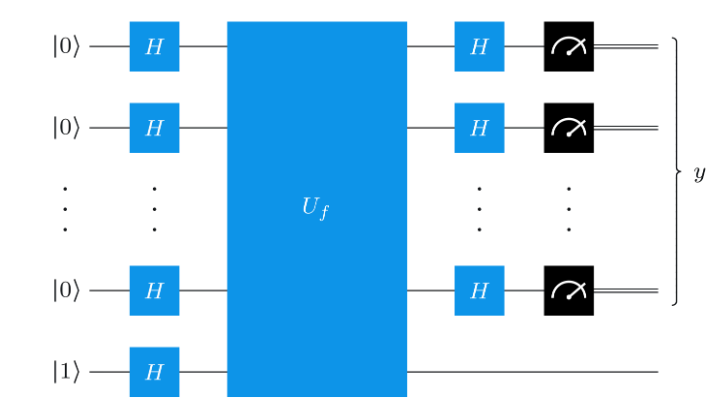

A rigorous explanation of the algorithm can be found on the [IBM Quantum learning](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#the-deutsch-jozsa-problem)

Intuitively, the algorithm proceeds as follows.

First, we create a superposition of all possible bit strings by applying a Hadamard gate to every qubit. This produces a uniform superposition of the computational basis states $|00...0\rangle,|00...1\rangle...,|11...1\rangle$.

Next, the oracle $U_f$ is applied. In quantum algorithms, applying an oracle plays the same role as calling the function $f$ in the classical setting. Since the oracle acts on a superposition of all possible input strings, it effectively evaluates the function $f$ on all inputs simultaneously.

A final layer of Hadamard gates removes the superposition created by the first layer, causing interference between amplitudes.

Finally, we measure the observable $Z$ on each qubit.

* If the function is constant, the measurement outcome is the string $00\ldots0$.
* If the function is balanced, the measurement outcome is guaranteed to be a string different from $00\ldots0$.

Note:
The Deutsch–Jozsa algorithm requires an oracle implementation of the function $f$. However, in order to construct the oracle as a quantum circuit, we must already know the function $f$. If we know $f$, then we already know whether it is constant or balanced, and there would be no need to run the algorithm.
For this reason, the Deutsch–Jozsa algorithm does not currently have a practical real-world application. Nevertheless, it remains an exceptionally powerful pedagogical tool for understanding quantum query algorithms and quantum computational advantage.

### Exercise 2

Given the oracles `Uf1` and `Uf2`, construct the Deutsch–Jozsa algorithm and determine whether the corresponding functions are constant or balanced.

Note: To append a quantum circuit `qc2` to another circuit `qc1`, you can use: `qc1.compose(qc2, inplace=True)`
Additionally, remember that in the measurement results you are not interested in the outcome of the last qubit (which corresponds to the first qubit in Qiskit’s little-endian ordering).

In [2]:
from qiskit import QuantumCircuit
from utils_2 import Uf
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

# Number of input bits (one less than total qubits in the algorithm)
N = 8

Uf1 = Uf(N, 6)
Uf2 = Uf(N, 3)

qc = QuantumCircuit(N + 1)

# WRITE YOUR CODE HERE
qc.x(N)
qc.h(range(N + 1))

qc.compose(Uf1, inplace=True)  # replace with Uf2 to test the other oracle

# WRITE YOUR CODE HERE
qc.h(range(N))

qc.measure_all()

# Run the circuit
job = sampler.run([qc], shots=1)
result = job.result()[0]
data_pub = result.data
bitstrings = data_pub.meas.get_counts()

# Ignore the ancilla qubit (first bit in Qiskit ordering)
measured_string = list(bitstrings.keys())[0][1:]

if "1" in measured_string:
    print("balanced")
else:
    print("constant")

constant


## Variational Quantum Eigensolver (VQE)

Variational algorithms are characterized by the use of a classical optimization routine that iteratively updates a parameterized quantum circuit, known as an ansatz.
One of the most prominent methods in this class is the [Variational Quantum Eigensolver (VQE)](https://learning.quantum.ibm.com/tutorial/variational-quantum-eigensolver), which aims to determine the lowest possible energy of a quantum system.

In VQE, the variational procedure consists of adjusting the circuit parameters in order to minimize the measured energy. At each iteration:

1. The parameterized circuit is executed.
2. The energy expectation value is measured.
3. A classical optimizer proposes a new set of parameters that (ideally) lowers the energy.

This process is repeated until a predefined convergence criterion is satisfied (for example, reaching a target precision or a maximum number of iterations).

To describe the total energy of a quantum system, one typically uses the Hamiltonian operator $H$. In quantum mechanics, every Hamiltonian has an associated energy spectrum, representing the set of possible total energies of the system.

The quantum state with the lowest energy is called the ground state, while the higher-energy states are referred to as excited states.

Understanding the properties of the ground state is crucial because, at sufficiently low temperatures, the physical behavior of a system is largely determined by the properties of its ground state.

### Our Hamiltonian

In this notebook, we study the Hamiltonian of the one-dimensional transverse-field Ising model:
$$
H = -\sum_{i=1}^{N-1} Z_i Z_{i+1}-\sum_{i=1}^N X_i \, ,
$$

where the subscript $i$ specifies which spin (qubit) the operator acts on. 
* $Z_i$ means: apply the Pauli-$Z$ operator to spin $i$, and apply the identity operator to all other spins.
* $X_i$ means: apply the Pauli-$X$ operator to spin $i$, and apply the identity operator to all other spins.
* The term $Z_i Z_{i+1}$ represents an interaction between neighboring spins. It means: $I \otimes \cdots \otimes Z \otimes Z \otimes \cdots \otimes I$, where the two 
$Z$ operators act on spins $i$ and $i+1$.

In [3]:
from qiskit.quantum_info import SparsePauliOp

N = 4 # We study a 4-qubit system for fast emulation times

list_of_paulis = []
for i in range(N-1):
    s = "I" * (N-1)
    s = s[:i] + "ZZ" + s[i+1:]
    list_of_paulis.append((s,-1))

for i in range(N):
    s = "I" * N
    s = s[:i] + "X" + s[i+1:]
    list_of_paulis.append((s,-1))
hamiltonian = SparsePauliOp.from_list(list_of_paulis)

print(hamiltonian)

SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])


### Variational Ansatz

To construct the ansatz — that is, the structure of our parameterized quantum circuit — we will use the architecture proposed in this [article](https://arxiv.org/abs/1803.00026).

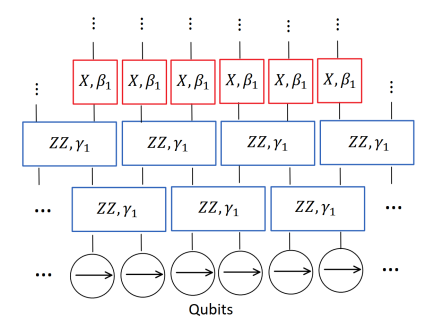

In [4]:
P = 2 # number of layers
def parameterized_circuit(params):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    for j in range(0,2*P,2):
        for i in range(0,N-1,2):
            qc.rzz(params[j],i,i+1)
        for i in range(1,N-1,2):
            qc.rzz(params[j],i,i+1)
        for i in range(N):
            qc.rx(params[j+1],i)
    return qc


### Optimization Process

We now aim to determine the optimal set of parameters for our problem — that is, the set of parameters that allows us to compute an energy value as close as possible to the ground-state energy.
As previously discussed, we will use the observable $H$ to evaluate the energy of the system. Specifically, we are interested in the expectation value of this observable, which corresponds to the average energy of the state prepared by the circuit.
In the ideal case, this average energy would exactly match the ground-state energy. However, in most practical situations, determining the exact ground-state energy is extremely difficult. Instead, we typically aim to obtain a sufficiently accurate approximation that can be used to infer relevant physical properties of the system.

To begin the optimization procedure, we generate an initial set of random parameters.

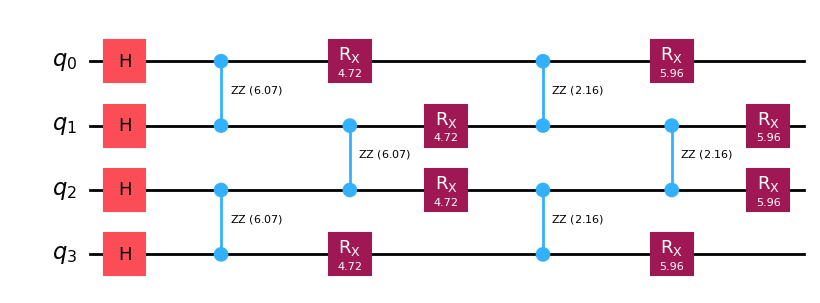

In [5]:
import numpy as np

params_init = np.random.uniform(0,2*np.pi,size=(2*P)) # random initial angles
parameterized_circuit(params_init).draw('mpl')

We define a `StatevectorEstimator` to compute the expectation value of the energy.

In [6]:
from qiskit.primitives import StatevectorEstimator
estimator = StatevectorEstimator()

We now compute the average energy of the state implemented by the circuit.

In [7]:
def energy_calculation(params):
    qc = parameterized_circuit(params)
    pub = (qc, hamiltonian)
    job = estimator.run([pub])

    result = job.result()[0]
    return result.data.evs

Next, we use a classical optimization algorithm based on gradient descent to iteratively update the circuit parameters in order to obtain progressively lower energy values.

In [8]:
from scipy.optimize import minimize
from utils_2 import adam, parameter_shift_rule


iterations = 100 # Number of iterations of the variational process

energies = []

def callback(x):
    energies.append(energy_calculation(x))


res = minimize(
                energy_calculation,
                params_init,
                method = adam,
                jac = parameter_shift_rule,
                callback = callback,
                options = {'maxiter':iterations}
            )
print(res)
exact_gs_energy = -4.75877048

 success: True
     fun: -4.241627554573091
       x: [ 5.887e+00  4.719e+00 -6.728e-01  5.960e+00]
     nit: 99
     jac: [ 4.597e-02 -2.220e-16 -3.206e-02  0.000e+00]
    nfev: 99


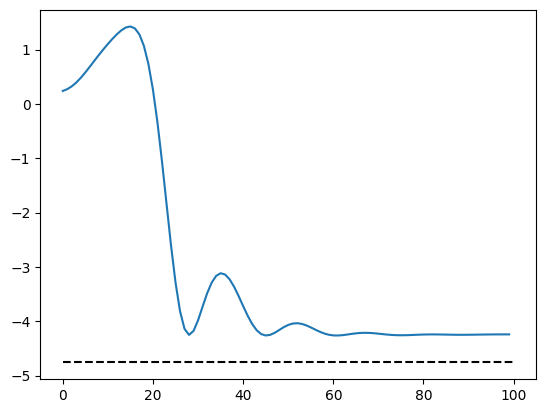

In [9]:
import matplotlib.pyplot as plt

plt.plot(energies)
plt.hlines(-4.75877048, 0, iterations,linestyles='--', colors = 'k')

### Exercise 3

Using the tools introduced above, compute the ground-state energy of the following Hamiltonian:
$$
H = -\sum_{i=1}^{N-1} J_{i} Z_iZ_{i+1}-\sum_{i=1}^N X_i \, ,
$$
where $J_i$ are the spin–spin coupling coefficients, given by $[-0.0421691, -0.87544104, 0.76848286]$.

Note:
You will need to modify the definition of the Hamiltonian accordingly, and you may also adjust the circuit ansatz if necessary.

 success: True
     fun: -2.6827961322104805
       x: [ 3.512e+00  5.281e+00 -9.502e-01  3.496e-01  3.557e+00
            1.914e+00]
     nit: 99
     jac: [-4.366e-03 -1.332e-15 -9.352e-03 -8.882e-16 -7.257e-03
            2.220e-16]
    nfev: 99
1.6529714181554183


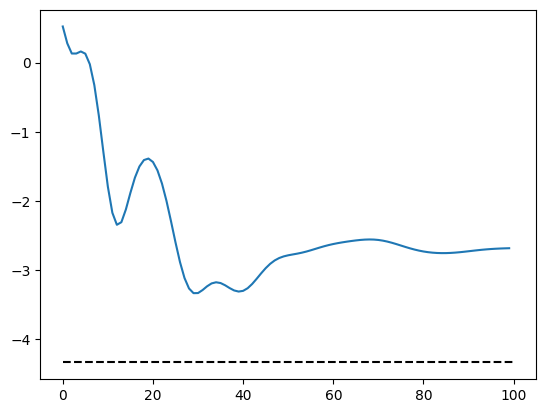

In [10]:
N = 4  # number of qubits
J = [-0.0421691, -0.87544104, 0.76848286]  # coupling constants

list_of_paulis = []

# WRITE YOUR CODE HERE
for i in range(N-1):
    s = "I" * N
    s = s[:i] + "ZZ" + s[i+2:]
    list_of_paulis.append((s, -J[i]))
    
for i in range(N):
    s = "I" * N
    s = s[:i] + "X" + s[i+1:]
    list_of_paulis.append((s, -1))

hamiltonian = SparsePauliOp.from_list(list_of_paulis)

def parameterized_circuit(params):
    qc = QuantumCircuit(N)

    # WRITE YOUR CODE HERE

    qc.h(range(N))
    param_index = 0
    for _ in range(P):
        for i in range(0, N-1, 2):
            qc.rzz(params[param_index], i, i+1)
        for i in range(1, N-1, 2):
            qc.rzz(params[param_index], i, i+1)
        param_index += 1
        for i in range(N):
            qc.rx(params[param_index], i)
        param_index += 1
    return qc

P = 3 # WRITE YOUR CODE HERE
params_init = np.random.uniform(0, 2*np.pi, 2*P)# WRITE YOUR CODE HERE

iterations = 100

def energy_calculation(params):
    qc = parameterized_circuit(params)
    pub = (qc, hamiltonian)
    job = estimator.run([pub])

    result = job.result()[0]
    return result.data.evs

energies = []

res = minimize(
                energy_calculation,
                params_init,
                method=adam,
                jac = parameter_shift_rule,
                callback = callback,
                options={'maxiter':iterations}
            )
print(res)

exact_gs_energy = -4.337305123613742
plt.plot(energies)
plt.hlines(-4.337305123613742, 0, iterations,linestyles='--', colors = 'k')
print(np.abs(energies[-1]-(-4.337305123613742)))

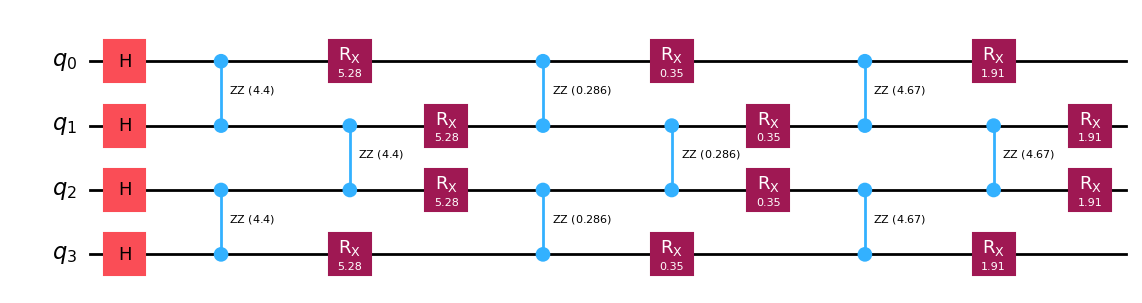

In [11]:
parameterized_circuit(params_init).draw('mpl')